# Spectral representation and topology recovery

## Ablation and neighbourhood-size study

**Question.** Which compact simulation descriptors give a stable spectral representation of the topology state diagram?

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import cmasher as cmr
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

from topology_state_map import TOPOLOGY_COLORS, TOPOLOGY_LABELS, build_topology_state_map

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
})

HERE = Path.cwd().resolve()
PROJECT = HERE if (HERE / 'results').is_dir() else HERE / 'rigid_magnetic'
if not (PROJECT / 'results').is_dir():
    raise FileNotFoundError('Run this notebook from rigid_magnetic or the repository root.')

RUN_NAME = 'MAG2P_order_parameters_with_crystallinity_20260803-174008-847690_k32_cryst-coarse-histograms'
ABLATION = PROJECT / 'results' / RUN_NAME / 'ablation'
ROBUSTNESS = ABLATION / 'spectral_neighbourhood_robustness_final' / 'data'
CONNECTIVITY = ABLATION / 'connectivity_recovery' / 'data'

labels = {
    'gofr': 'g(r)',
    'orientation__gofr': 'orientation + g(r)',
    'orientation__Rg': 'orientation + Rg',
    'full_reference': 'full reference',
}
colors = {
    'gofr': '#2B6CB0',
    'orientation__gofr': '#008F7A',
    'orientation__Rg': '#B7791F',
    'full_reference': '#7B2CBF',
}
selected_sets = ['gofr', 'orientation__gofr', 'orientation__Rg', 'full_reference']
topology_categories = ['chain', 'liquid', 'complex_network', 'ring', 'strongly_clustered']
category_labels = ['chain', 'liquid', 'complex network', 'ring', 'strongly clustered']
category_colors = ['#000000', '#86878A', '#1CA879', '#591FDF', '#EEBF25']

## 1. Scope

The completed study contains 2,760 simulation runs. Five descriptor groups were combined in 31 ways: global observables, orientation, Rg, g(r), and coarse crystallinity histograms. The report focuses on four representative descriptor sets that were carried through the neighbourhood-size study.

In [2]:
feature_groups = pd.DataFrame([
    ('global', 6, 'mean bonds, cluster size, largest cluster, mean Rg'),
    ('orientation', 24, 'pair-orientation histogram bins'),
    ('Rg', 29, 'radius of gyration by bonded-cluster size'),
    ('g(r)', 25, 'radial-distribution-function bins'),
    ('crystallinity histograms', 20, 'coarse q4 and q6 histogram bins'),
], columns=['feature group', 'variables', 'summary'])
feature_groups

,feature group,variables,summary
0,global,6,"mean bonds, cluster size, largest cluster, mea..."
1,orientation,24,pair-orientation histogram bins
2,Rg,29,radius of gyration by bonded-cluster size
3,g(r),25,radial-distribution-function bins
4,crystallinity histograms,20,coarse q4 and q6 histogram bins


### Selected comparison sets

The main report compares three reduced descriptor sets with the full 104-variable reference. All 31 non-empty group combinations and their dimensions are listed in the appendix.

In [3]:
selected_table = pd.DataFrame([
    ('g(r)', 25, 'compact radial-structure baseline'),
    ('orientation + g(r)', 49, 'best topology-recovery representation'),
    ('orientation + Rg', 53, 'cluster compactness and size contrast'),
    ('full reference', 104, 'all-feature benchmark'),
], columns=['selected comparison set', 'variables', 'purpose'])
selected_table

,selected comparison set,variables,purpose
0,g(r),25,compact radial-structure baseline
1,orientation + g(r),49,best topology-recovery representation
2,orientation + Rg,53,cluster compactness and size contrast
3,full reference,104,all-feature benchmark


**How were these four chosen?**

- **Spearman correlation** tests whether graph neighbours preserve the ordering of a physical observable. For every run, mean bond number or mean cluster size is predicted by averaging that quantity over its 31 graph neighbours; Spearman compares the rank order of this prediction with the measured value. A value of 1 is perfect rank preservation. Representations containing the global bond and size observables are excluded from this physical ranking.
- **5-NN topology error** tests the state diagram directly. For each held-out lambda/shift state, 5-NN averages the five topology-composition vectors of the nearest training states in psi-space. The prediction is compared with the observed five-fraction mixture; lower error is better.
- **Graph similarity** is the fraction of neighbours shared with the all-feature reference graph. It measures similarity to that reference graph, not independent topology or physical accuracy.

**Quantitative selection.** The 31-combination ablation was evaluated at k = 32. `g(r)` has 25 variables and ranks first among reduced sets without global observables on the recorded bond/mean-size neighbour-consistency criterion (Spearman = 0.993 and 0.983). Orientation + `g(r)` has 49 variables and gives the best 5-NN topology recovery (mean error = 0.080, macro R2 = 0.938). Orientation + Rg has 53 variables and is retained as the physically distinct cluster-compactness comparison; its mean graph similarity to the full reference is 0.624. The 104-variable full reference is the all-feature benchmark (mean topology error = 0.090, macro R2 = 0.914).

## 2. Observed topology state diagram

This is the topology panel used in the original state diagram. At each lambda/shift state, the colour mixes the two dominant cluster-size-weighted topology fractions. Tree clusters are excluded, matching the original state-diagram definition.

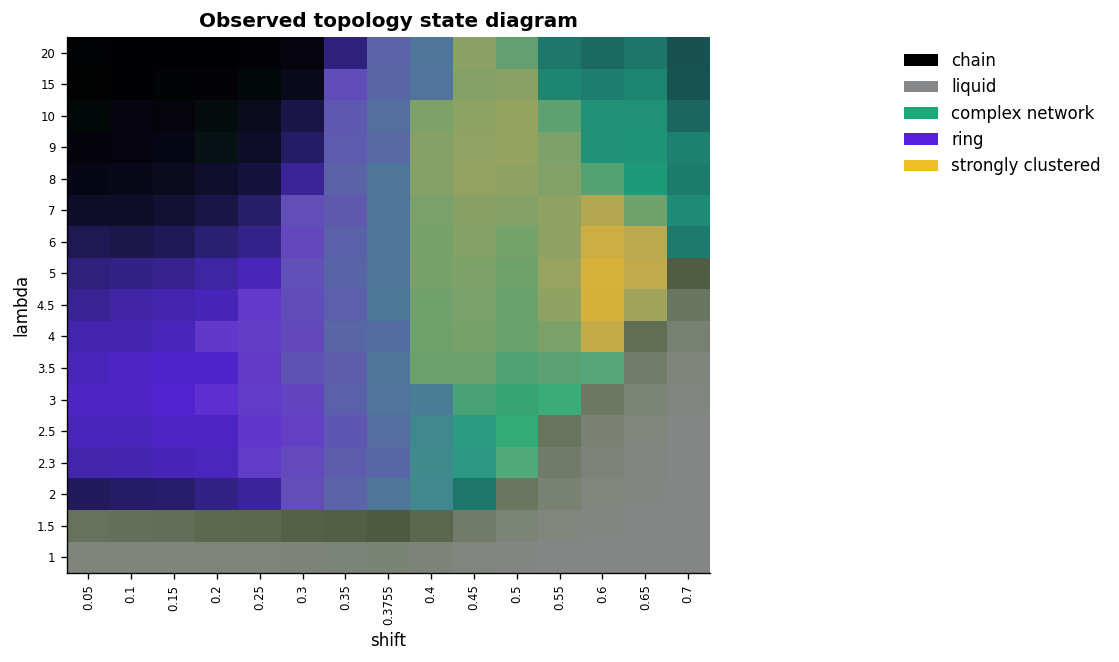

In [4]:
target_counts = pd.read_csv(ROBUSTNESS / 'topology_target_replica_counts.csv')
lambda_values = np.sort(target_counts['lambda'].unique())
shift_values = np.sort(target_counts['shift'].unique())
topology_path = PROJECT / 'results' / 'MAG2P_order_parameters_per_cluster-2026-1-13-18:15:54.pickle'
state_map = build_topology_state_map(topology_path, lambda_values, shift_values)

fig, ax = plt.subplots(figsize=(9, 5.8))
ax.imshow(state_map.rgba, origin='lower', aspect='auto')
ax.set(
    title='Observed topology state diagram', xlabel='shift', ylabel='lambda',
    xticks=np.arange(len(shift_values)), xticklabels=[f'{value:g}' for value in shift_values],
    yticks=np.arange(len(lambda_values)), yticklabels=[f'{value:g}' for value in lambda_values],
)
ax.tick_params(axis='x', labelrotation=90, labelsize=7)
ax.tick_params(axis='y', labelsize=7)
legend = [Patch(facecolor=TOPOLOGY_COLORS[name], label=TOPOLOGY_LABELS[name]) for name in topology_categories]
ax.legend(handles=legend, loc='upper left', bbox_to_anchor=(1.28, 1), frameon=False)
fig.subplots_adjust(right=0.72)
plt.show()

**How to read this plot.** Pure colours denote one dominant topology class; mixed colours denote states where two classes contribute substantially. This observed map is the target that the 5-NN analysis attempts to recover from spectral coordinates.

## 3. How do the selected descriptor sets organize the state diagram?

Each row below is one selected representation at k = 32. The three columns are its first three state-averaged spectral coordinates.

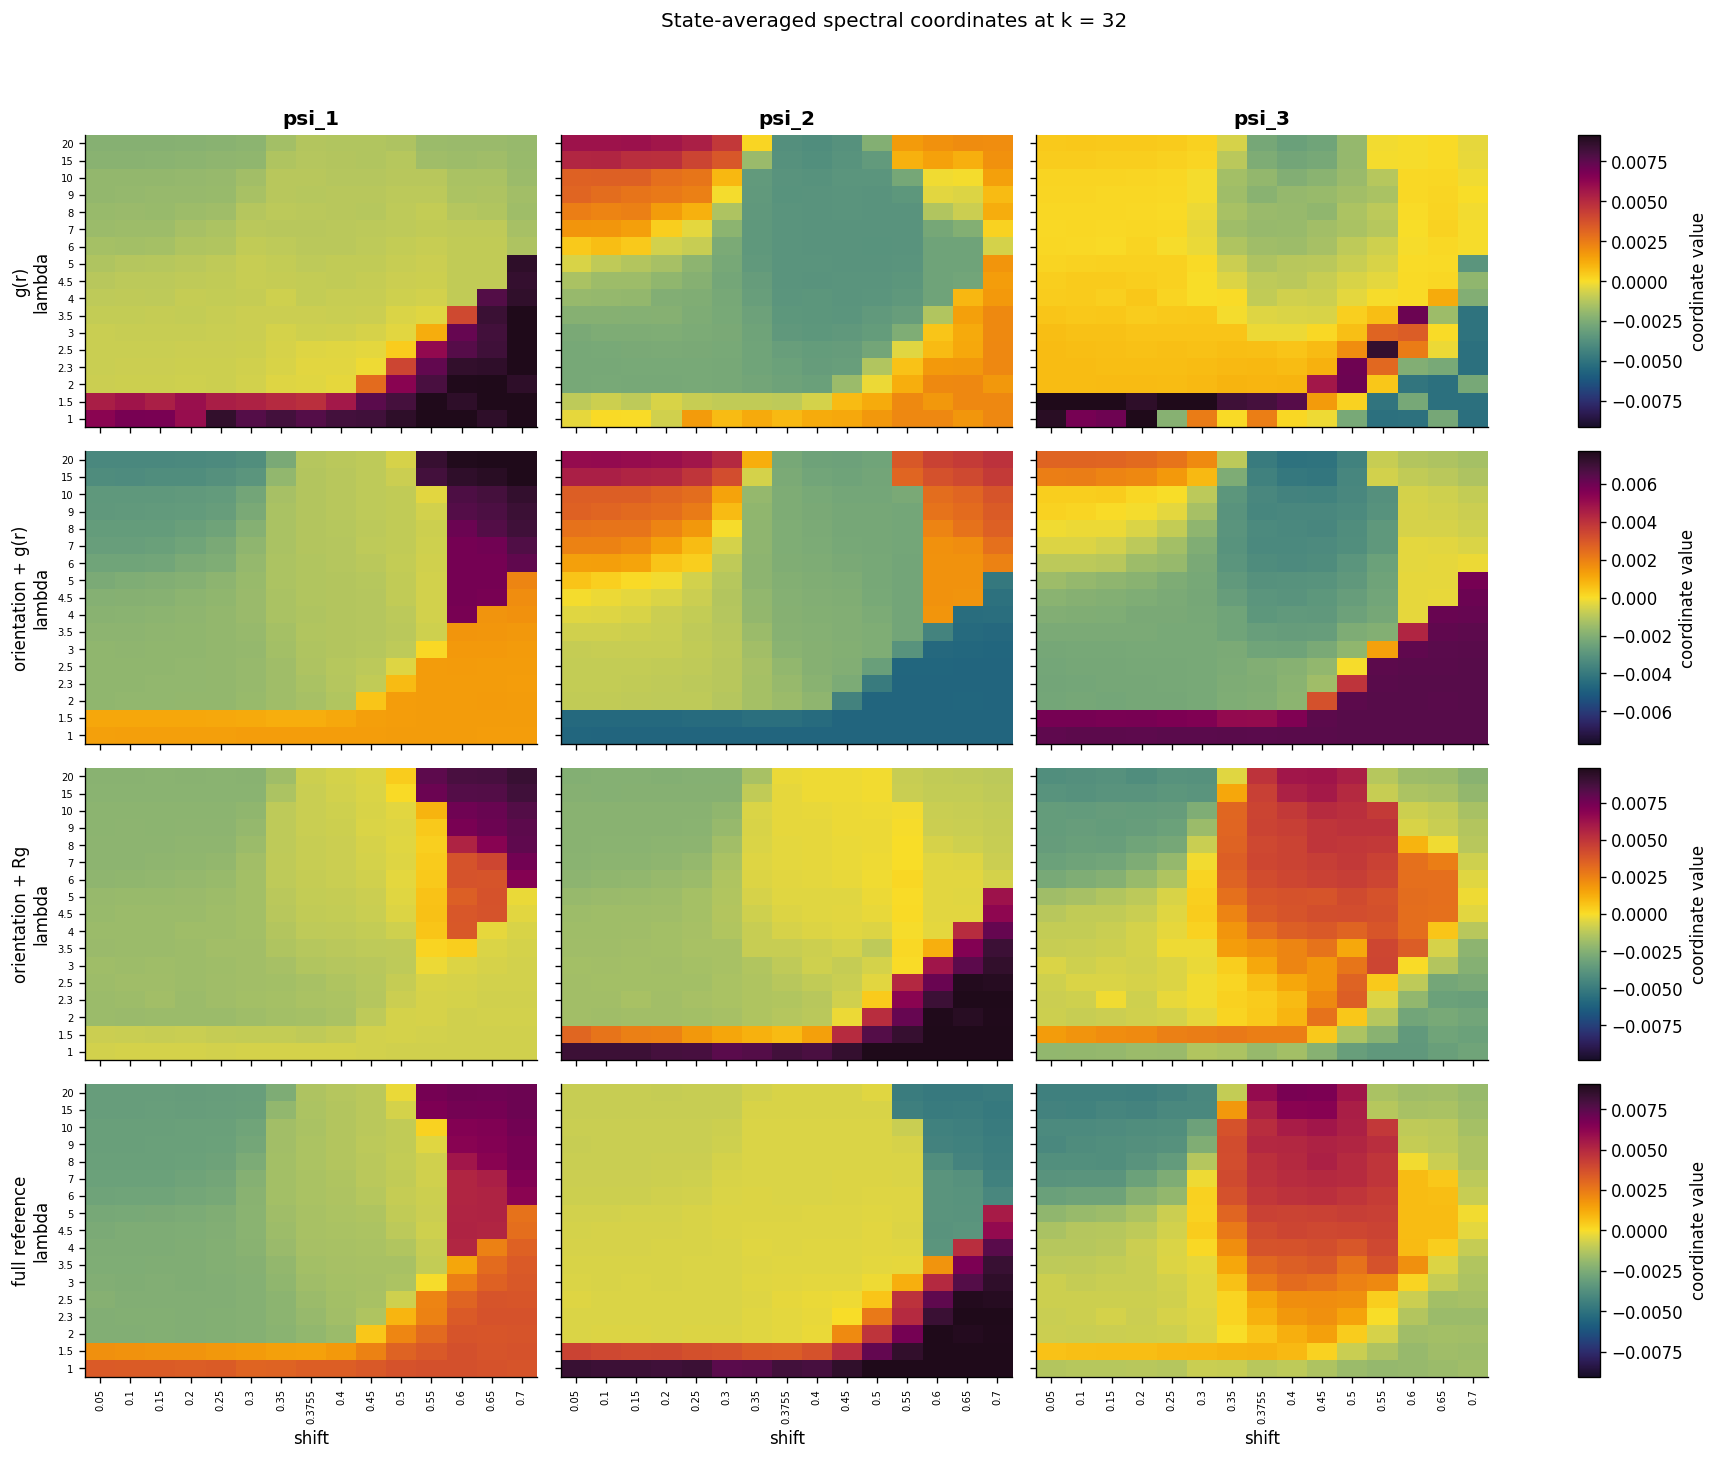

In [5]:
state_coordinates = pd.read_csv(ROBUSTNESS / 'final_state_averaged_coordinates.csv')

def coordinate_grid(frame, column):
    return (frame.pivot(index='lambda', columns='shift', values=column)
                 .reindex(index=lambda_values, columns=shift_values)
                 .to_numpy(dtype=float))

fig, axes = plt.subplots(len(selected_sets), 3, figsize=(15, 12), sharex=True, sharey=True)
row_images = []
for row, feature_set in enumerate(selected_sets):
    data = state_coordinates.loc[(state_coordinates['feature_set'] == feature_set) & (state_coordinates['k_graph'] == 32)]
    limit = np.quantile(np.abs(data[['psi_1', 'psi_2', 'psi_3']].to_numpy()), 0.99)
    for column, coordinate in enumerate(['psi_1', 'psi_2', 'psi_3']):
        image = axes[row, column].imshow(coordinate_grid(data, coordinate), origin='lower', aspect='auto',
                                             cmap=cmr.pride, vmin=-limit, vmax=limit)
        if row == 0:
            axes[row, column].set_title(coordinate)
        if column == 0:
            axes[row, column].set_ylabel(f'{labels[feature_set]}\nlambda')
        if row == len(selected_sets) - 1:
            axes[row, column].set_xlabel('shift')
        axes[row, column].set_xticks(np.arange(len(shift_values)))
        axes[row, column].set_xticklabels([f'{value:g}' for value in shift_values], rotation=90, fontsize=6)
        axes[row, column].set_yticks(np.arange(len(lambda_values)))
        axes[row, column].set_yticklabels([f'{value:g}' for value in lambda_values], fontsize=6)
    row_images.append(image)
fig.suptitle('State-averaged spectral coordinates at k = 32', y=1.01)
fig.tight_layout(rect=(0, 0, 0.84, 0.98))
for row, image in enumerate(row_images):
    position = axes[row, 2].get_position()
    color_axis = fig.add_axes([0.88, position.y0, 0.012, position.height])
    fig.colorbar(image, cax=color_axis, label='coordinate value')
plt.show()

**How to read these maps.** Within each row, red and blue identify states at opposite ends of a spectral coordinate. Compare the state-space patterns within a row. Coordinate signs and magnitudes are not directly comparable between rows because each representation has its own spectral embedding.

### Sample-level spectral views

The following scatter plots show all 2,760 simulation runs. They compare the full reference, the best reduced representation (orientation + g(r)), and g(r) alone. The CMasher `pride` colormap encodes the continuous shift and lambda parameters.

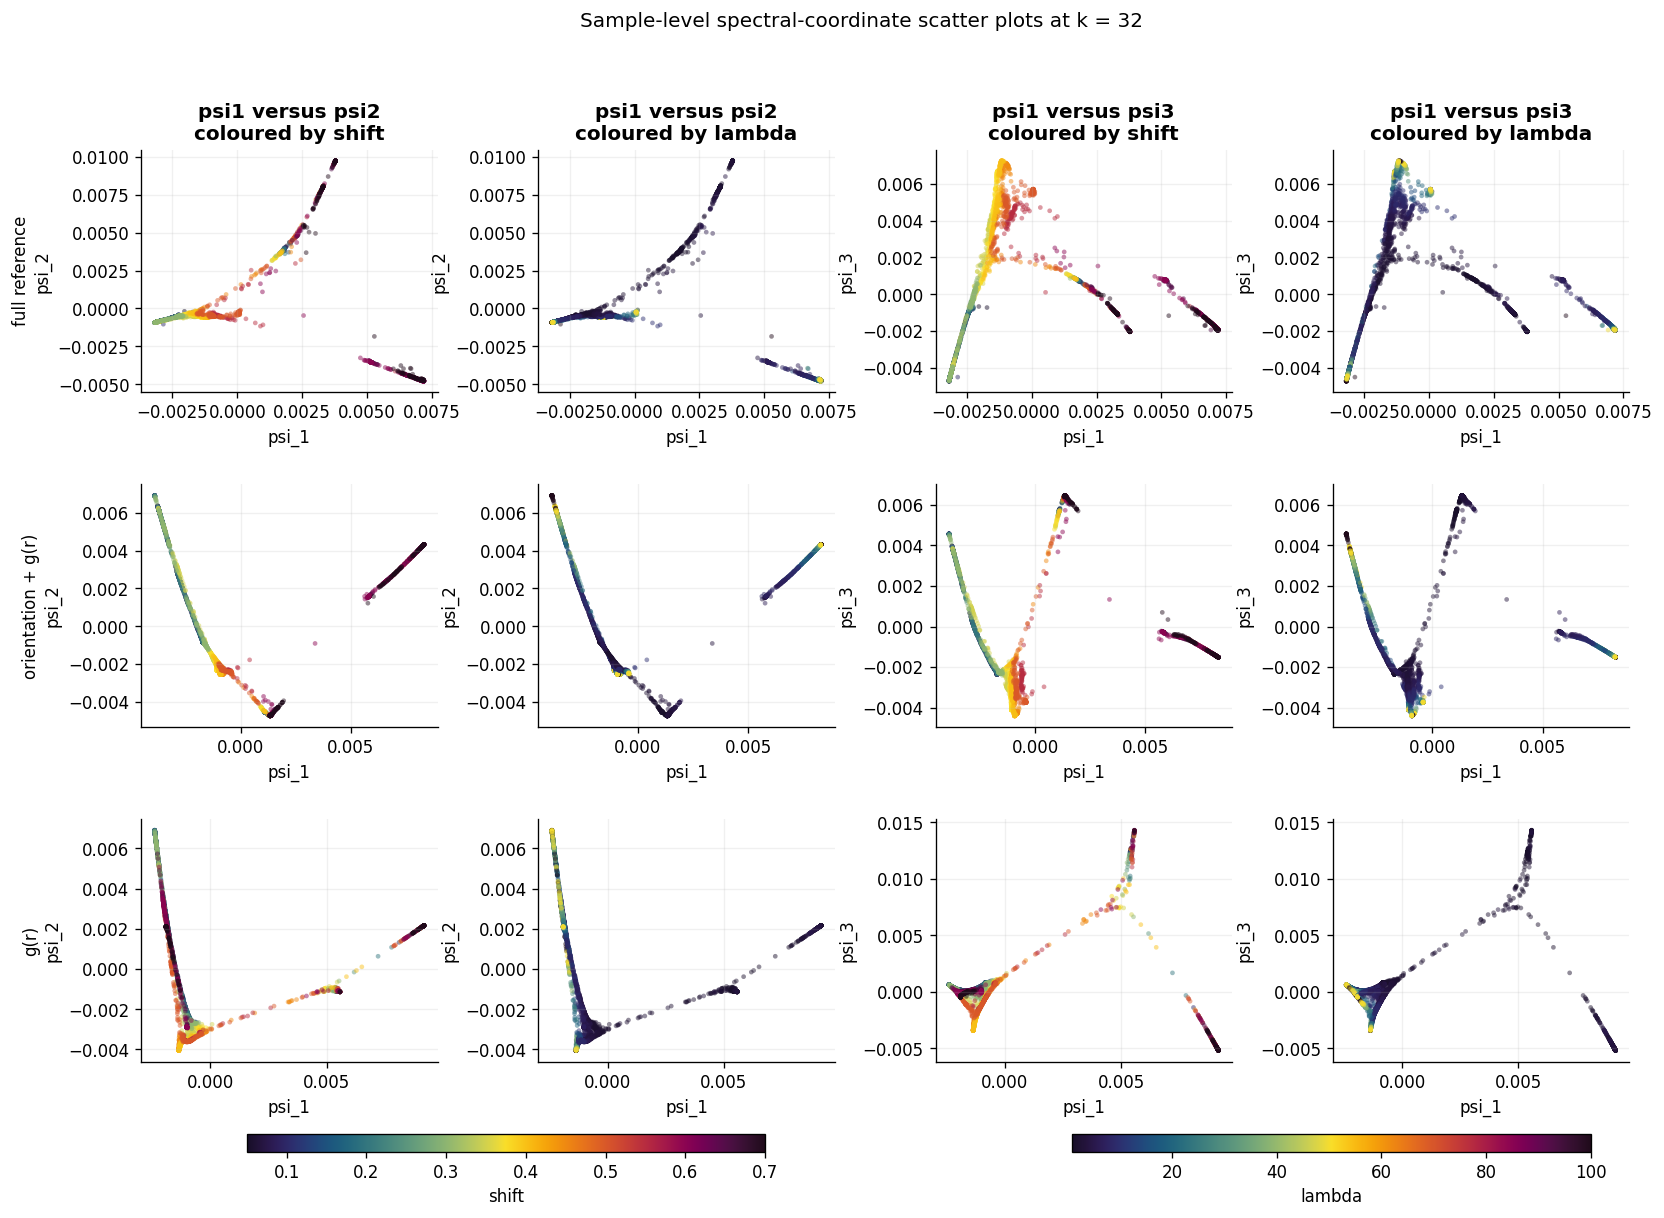

In [6]:
scatter_sets = ['full_reference', 'orientation__gofr', 'gofr']
scatter_paths = {
    'full_reference': ROBUSTNESS / 'final_sample_coordinates_full_reference.csv',
    'orientation__gofr': ROBUSTNESS / 'final_sample_coordinates_orientation__gofr.csv',
    'gofr': ROBUSTNESS / 'final_sample_coordinates_gofr.csv',
}
sample_coordinates = {feature_set: pd.read_csv(path) for feature_set, path in scatter_paths.items()}
shift_norm = plt.Normalize(min(frame['shift'].min() for frame in sample_coordinates.values()),
                           max(frame['shift'].max() for frame in sample_coordinates.values()))
lambda_norm = plt.Normalize(min(frame['lambda'].min() for frame in sample_coordinates.values()),
                            max(frame['lambda'].max() for frame in sample_coordinates.values()))
pairs = [('psi_1', 'psi_2', 'psi1 versus psi2'), ('psi_1', 'psi_3', 'psi1 versus psi3')]
colourings = [('shift', shift_norm), ('lambda', lambda_norm)]

fig, axes = plt.subplots(len(scatter_sets), 4, figsize=(16, 10), squeeze=False)
for row, feature_set in enumerate(scatter_sets):
    frame = sample_coordinates[feature_set]
    for pair_index, (x_column, y_column, pair_label) in enumerate(pairs):
        for colour_index, (parameter, norm) in enumerate(colourings):
            column = 2 * pair_index + colour_index
            axis = axes[row, column]
            axis.scatter(frame[x_column], frame[y_column], c=frame[parameter], cmap=cmr.pride, norm=norm,
                         s=8, alpha=0.48, linewidths=0, rasterized=True)
            if row == 0:
                axis.set_title(f'{pair_label}\ncoloured by {parameter}')
            if column == 0:
                axis.set_ylabel(f'{labels[feature_set]}\n{y_column}')
            else:
                axis.set_ylabel(y_column)
            axis.set_xlabel(x_column)
            axis.grid(alpha=0.18)
fig.subplots_adjust(bottom=0.12, hspace=0.38, wspace=0.34)
shift_bar = fig.add_axes([0.18, 0.045, 0.27, 0.015])
lambda_bar = fig.add_axes([0.61, 0.045, 0.27, 0.015])
fig.colorbar(plt.cm.ScalarMappable(norm=shift_norm, cmap=cmr.pride), cax=shift_bar, orientation='horizontal', label='shift')
fig.colorbar(plt.cm.ScalarMappable(norm=lambda_norm, cmap=cmr.pride), cax=lambda_bar, orientation='horizontal', label='lambda')
fig.suptitle('Sample-level spectral-coordinate scatter plots at k = 32', y=0.995)
plt.show()

**How to read these plots.** Each point is one simulation run; nearby points are spectrally similar under the representation named at the left. The shared `pride` colourbars make parameter gradients comparable across rows. These are continuous parameter colours, distinct from the categorical topology colours in the observed topology state diagram.

## 4. Topology target and scoring

Each lambda/shift state has eight replicas. For each state, cluster sizes are accumulated into five retained topology classes and normalized to a five-component composition vector. The state-level spectral coordinates are the replica-average of psi1, psi2, and psi3.

For a held-out state, 5-NN finds its five nearest training states in standardized psi-space and averages their known topology-composition vectors. The prediction is compared with the held-out composition. This is repeated in eight grouped folds, producing an out-of-fold score for every state.

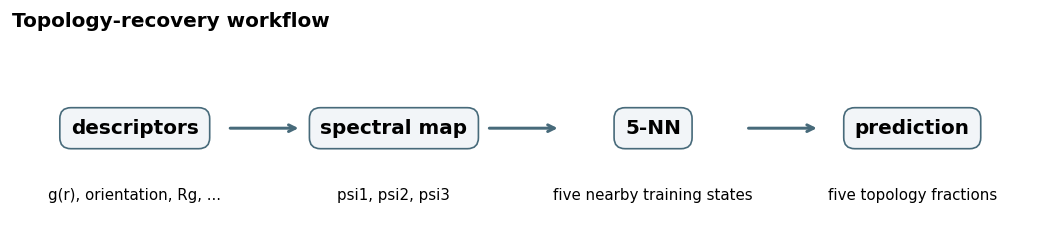

In [7]:
fig, ax = plt.subplots(figsize=(11, 2.2))
ax.axis('off')
steps = [
    ('descriptors', 'g(r), orientation, Rg, ...'),
    ('spectral map', 'psi1, psi2, psi3'),
    ('5-NN', 'five nearby training states'),
    ('prediction', 'five topology fractions'),
]
x_positions = np.linspace(0.12, 0.88, len(steps))
for index, ((title, subtitle), x) in enumerate(zip(steps, x_positions)):
    ax.text(x, 0.55, title, ha='center', va='center', fontsize=12, weight='bold',
            bbox={'boxstyle': 'round,pad=0.55', 'facecolor': '#F2F5F8', 'edgecolor': '#476A7A'})
    ax.text(x, 0.22, subtitle, ha='center', va='center', fontsize=9)
    if index < len(steps) - 1:
        ax.annotate('', xy=(x_positions[index + 1] - 0.09, 0.55), xytext=(x + 0.09, 0.55),
                    arrowprops={'arrowstyle': '->', 'lw': 1.8, 'color': '#476A7A'})
ax.set_title('Topology-recovery workflow', loc='left')
plt.show()

**How to read this workflow.** The input descriptors define which runs are neighbours; the spectral coordinates provide a low-dimensional location for each run; 5-NN transfers the topology mixture from nearby training states.

**Why use this score?** It tests whether local proximity in the spectral representation recovers the experimentally interpretable mixture of structural motifs.

## 3. Which descriptor set best recovers topology at k = 32?

This comparison changes only the descriptor set used to construct the spectral neighbourhood graph. The graph size, spectral-coordinate count, 5-NN decoder, topology target, and grouped validation are otherwise the same. Lower composition error is better.

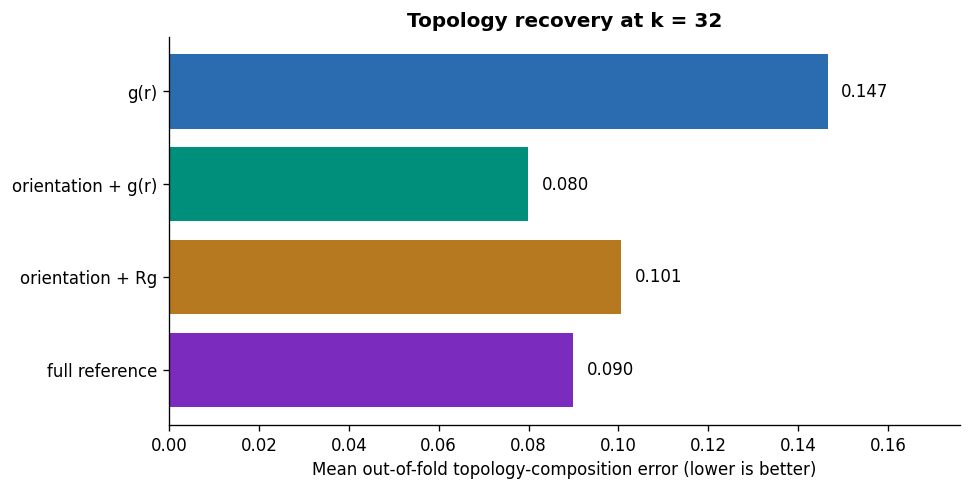

,representation,input columns,macro R2,mean OOF composition error
0,g(r),25,0.780363,0.146607
1,orientation + g(r),49,0.937957,0.079879
2,orientation + Rg,53,0.901418,0.100632
3,full reference,104,0.914318,0.089901


In [8]:
recovery = pd.read_csv(ROBUSTNESS / 'connectivity_recovery_scores_and_ranks.csv')
comparison = recovery.loc[
    (recovery['model'] == 'knn') & (recovery['k_graph'] == 32) & recovery['feature_set'].isin(selected_sets)
].copy()
comparison['label'] = comparison['feature_set'].map(labels)
comparison = comparison.set_index('feature_set').loc[selected_sets].reset_index()

fig, ax = plt.subplots(figsize=(8.5, 4.2))
bars = ax.barh(comparison['label'], comparison['mean_composition_error'],
               color=[colors[name] for name in comparison['feature_set']])
ax.invert_yaxis()
ax.set(xlabel='Mean out-of-fold topology-composition error (lower is better)',
       title='Topology recovery at k = 32')
for bar, value in zip(bars, comparison['mean_composition_error']):
    ax.text(value + 0.003, bar.get_y() + bar.get_height() / 2, f'{value:.3f}', va='center')
ax.set_xlim(0, comparison['mean_composition_error'].max() * 1.2)
plt.show()

comparison[['label', 'n_input_columns', 'macro_r2', 'mean_composition_error']].rename(columns={
    'label': 'representation',
    'n_input_columns': 'input columns',
    'macro_r2': 'macro R2',
    'mean_composition_error': 'mean OOF composition error',
})

**What is shown.** The bar chart reports the mean difference between the predicted and observed five-component topology vectors for held-out states.

**Conclusion.** Orientation + g(r) has the lowest error (0.080) and highest macro R2 (0.938). It is the best compact reduced representation for this topology-recovery task.

Orientation + Rg is included as a real-space cluster-compactness comparison. It does not contain topology labels or topology fractions.

## 5. Dedicated k-study: does the result depend on neighbourhood size?

The graph parameter k controls how many nearby simulations define local similarity. Very small k can split a graph into disconnected pieces; very large k can blur local distinctions. We tested k = 5, 10, 20, 28, 32, 36, 50, and 200.

### 5.1 Eigenvalue diagnosis

The normalized graph-Laplacian spectrum diagnoses graph connectivity. The number of near-zero eigenvalues equals the number of disconnected components: one near-zero mode means a connected graph; additional near-zero modes reveal fragmentation.

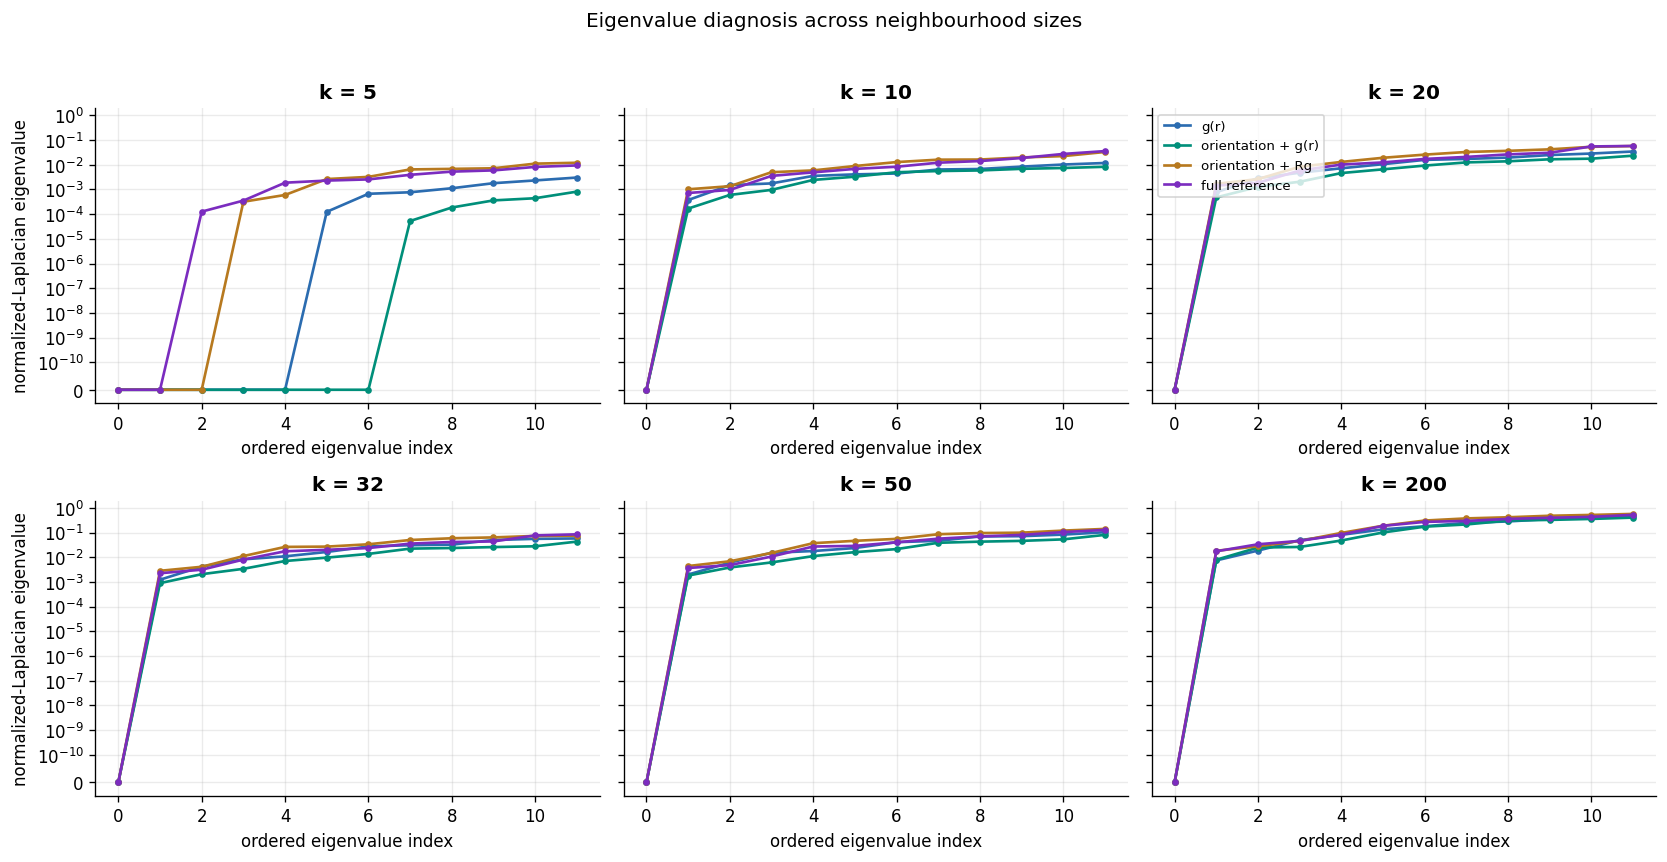

In [9]:
spectra = pd.read_csv(ROBUSTNESS / 'ordered_laplacian_spectra.csv')
spectrum_k_values = [5, 10, 20, 32, 50, 200]
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for ax, k_value in zip(axes.ravel(), spectrum_k_values):
    for feature_set in selected_sets:
        data = spectra.loc[(spectra['feature_set'] == feature_set) & (spectra['k_graph'] == k_value)
                           & (spectra['eigenvalue_index'] < 12)]
        ax.plot(data['eigenvalue_index'], data['eigenvalue'], marker='o', markersize=3, lw=1.6,
                color=colors[feature_set], label=labels[feature_set])
    ax.set(title=f'k = {k_value}', xlabel='ordered eigenvalue index')
    ax.set_yscale('symlog', linthresh=1e-10)
    ax.grid(alpha=0.25)
axes[0, 0].set_ylabel('normalized-Laplacian eigenvalue')
axes[1, 0].set_ylabel('normalized-Laplacian eigenvalue')
axes[0, 2].legend(fontsize=8, loc='upper left')
fig.suptitle('Eigenvalue diagnosis across neighbourhood sizes', y=1.02)
plt.tight_layout()
plt.show()

**How to read this plot.** At k = 5, several traces begin with extra near-zero modes, indicating multiple disconnected graph components. At k = 10 and above, the selected representations show one zero mode and are connected. The remaining spectral analysis therefore uses a graph neighbourhood that supports one coherent coordinate system.

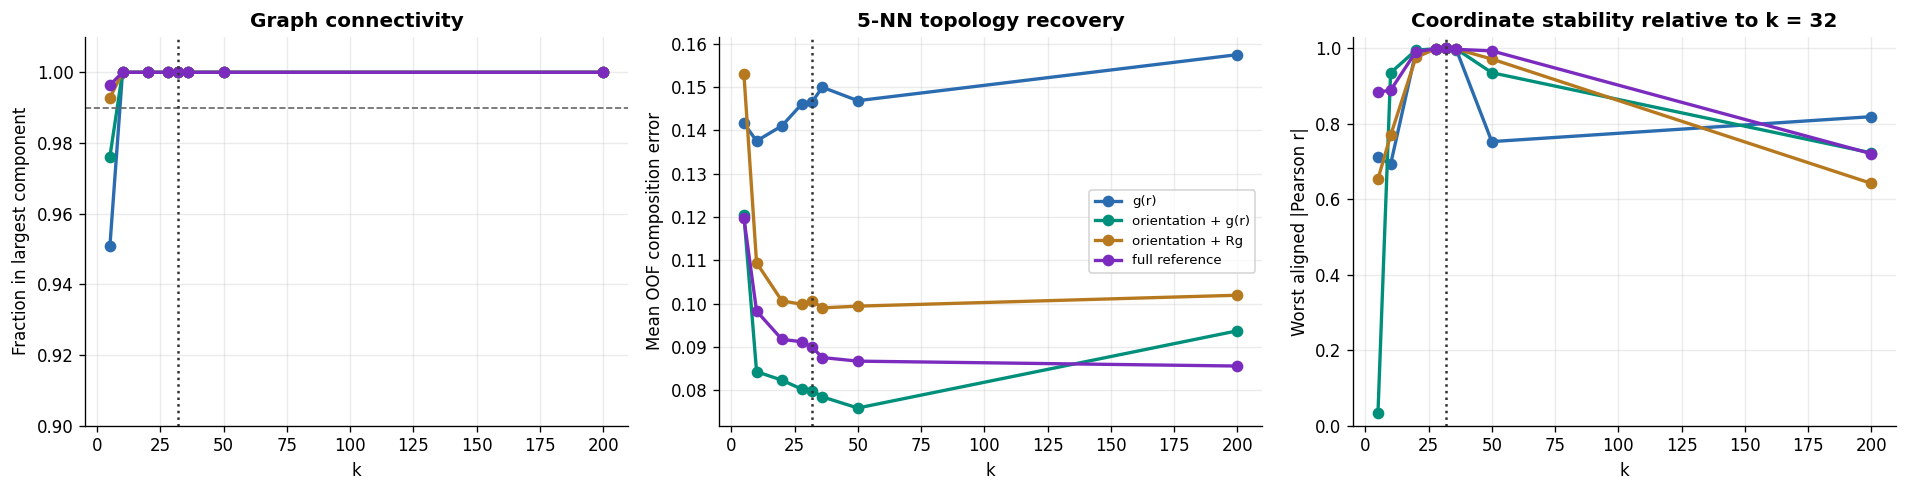

In [10]:
physical = pd.read_csv(ROBUSTNESS / 'physical_and_graph_scores_and_ranks.csv')
alignment = pd.read_csv(ROBUSTNESS / 'coordinate_alignment_and_degeneracy.csv')
knn_k = recovery.loc[(recovery['model'] == 'knn') & recovery['feature_set'].isin(selected_sets)].copy()
physical_k = physical.loc[physical['feature_set'].isin(selected_sets)].copy()
alignment_k = alignment.loc[alignment['feature_set'].isin(selected_sets)].copy()
alignment_k['absolute_alignment_r'] = alignment_k['alignment_pearson_r'].abs()
alignment_summary = alignment_k.groupby(['feature_set', 'k_graph'], as_index=False)['absolute_alignment_r'].min()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for feature_set in selected_sets:
    style = {'color': colors[feature_set], 'marker': 'o', 'lw': 2}
    component = physical_k.loc[physical_k['feature_set'] == feature_set]
    score = knn_k.loc[knn_k['feature_set'] == feature_set]
    stable = alignment_summary.loc[alignment_summary['feature_set'] == feature_set]
    axes[0].plot(component['k_graph'], component['fraction_in_largest'], label=labels[feature_set], **style)
    axes[1].plot(score['k_graph'], score['mean_composition_error'], label=labels[feature_set], **style)
    axes[2].plot(stable['k_graph'], stable['absolute_alignment_r'], label=labels[feature_set], **style)

axes[0].axhline(0.99, color='#666666', ls='--', lw=1, label='99% threshold')
for ax in axes:
    ax.axvline(32, color='#333333', ls=':', lw=1.5)
    ax.grid(alpha=0.25)
    ax.set_xlabel('k')
axes[0].set(title='Graph connectivity', ylabel='Fraction in largest component', ylim=(0.9, 1.01))
axes[1].set(title='5-NN topology recovery', ylabel='Mean OOF composition error')
axes[2].set(title='Coordinate stability relative to k = 32', ylabel='Worst aligned |Pearson r|', ylim=(0, 1.03))
axes[1].legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

**What is shown.** Left: whether each graph remains connected. Middle: out-of-fold 5-NN topology error. Right: the least stable of psi1, psi2, and psi3 after alignment to the k = 32 coordinates. The vertical line marks the selected k.

**Why it is shown.** A useful neighbourhood size must produce a connected graph, preserve the spectral-coordinate interpretation, and retain the topology-recovery result.

**Conclusion.** k = 5 fragments some reduced graphs. From k = 10 onward, the selected graphs are connected; orientation + g(r) remains the strongest topology representation over the practical range. k = 32 is a stable operating choice rather than an isolated optimum.

## 6. What does the best prediction look like?

The following maps compare the observed state-diagram topology fractions with out-of-fold 5-NN predictions made from the orientation + g(r) spectral representation at k = 32. Each column is one topology class; rows are observed and predicted compositions.

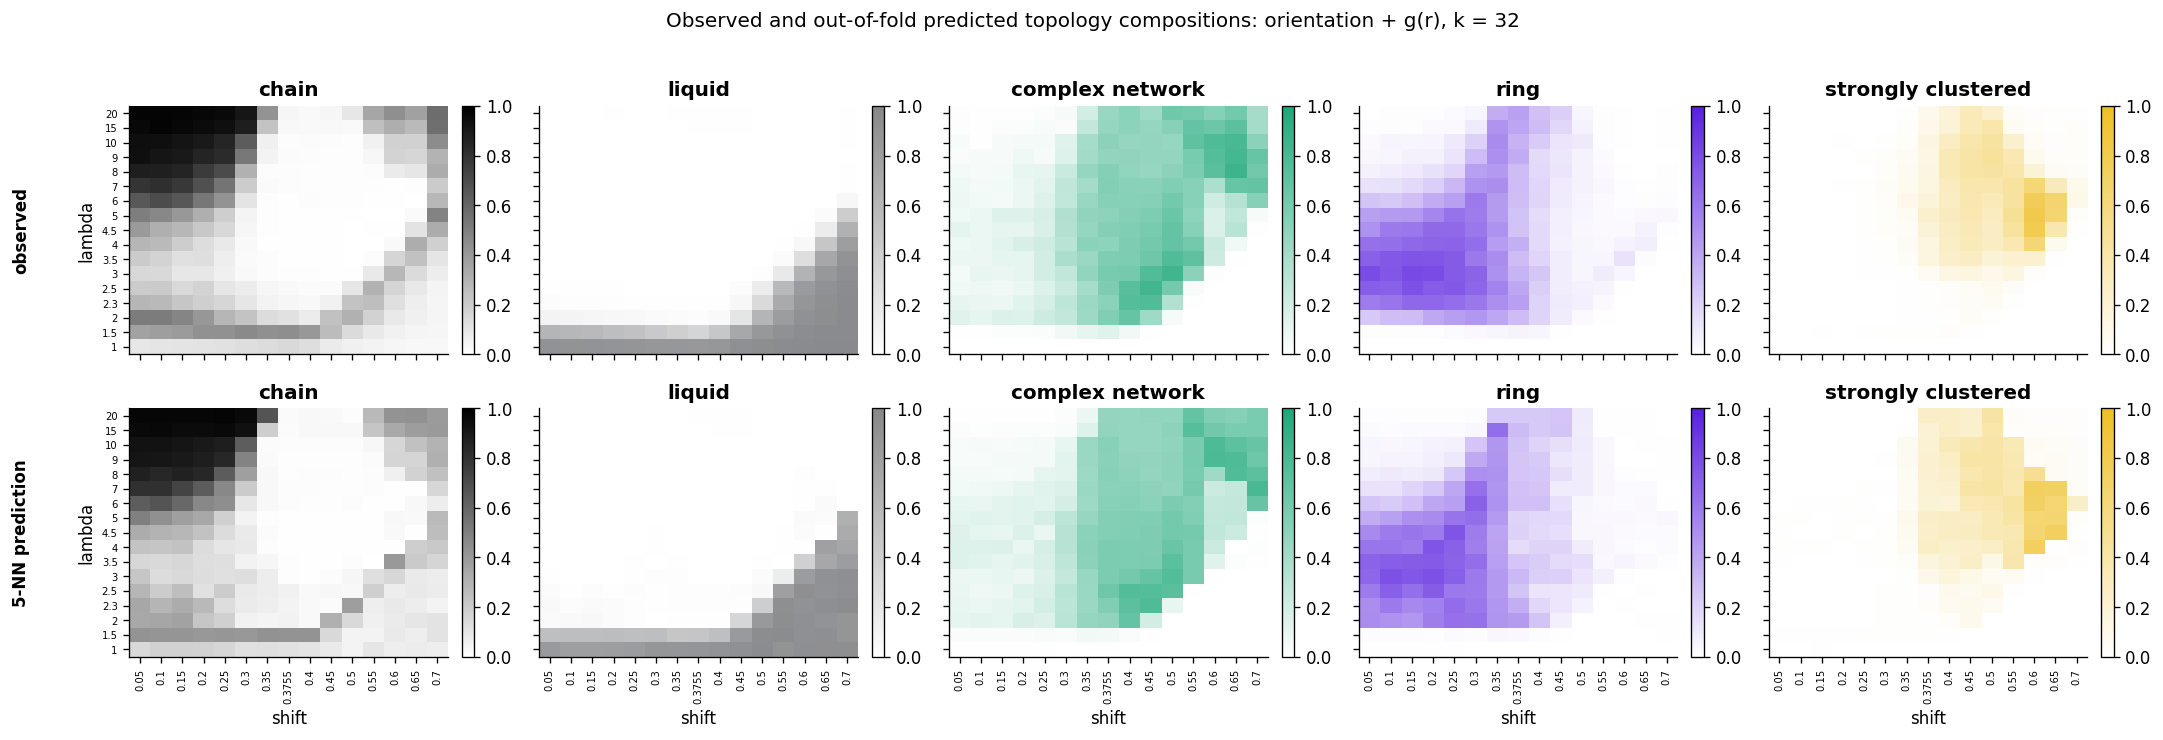

In [11]:
predictions = pd.read_csv(ROBUSTNESS / 'connectivity_oof_predictions.csv')
best = predictions.loc[
    (predictions['feature_set'] == 'orientation__gofr')
    & (predictions['model'] == 'knn')
    & (predictions['k_graph'] == 32)
].copy()
lambda_values = np.sort(best['lambda'].unique())
shift_values = np.sort(best['shift'].unique())

def state_grid(frame, column):
    return (frame.pivot(index='lambda', columns='shift', values=column)
                 .reindex(index=lambda_values, columns=shift_values)
                 .to_numpy(dtype=float))

fig, axes = plt.subplots(2, len(topology_categories), figsize=(18, 6), sharex=True, sharey=True)
for column, (category, category_label, color) in enumerate(zip(topology_categories, category_labels, category_colors)):
    for row, prefix in enumerate(['observed_', 'predicted_']):
        image = axes[row, column].imshow(
            state_grid(best, prefix + category), origin='lower', aspect='auto',
            cmap=LinearSegmentedColormap.from_list(category, ['#FFFFFF', color]),
            vmin=0, vmax=1,
        )
        axes[row, column].set_title(category_label)
        axes[row, column].set_xticks(np.arange(len(shift_values)))
        axes[row, column].set_xticklabels([f'{value:g}' for value in shift_values], rotation=90, fontsize=6)
        axes[row, column].set_yticks(np.arange(len(lambda_values)))
        axes[row, column].set_yticklabels([f'{value:g}' for value in lambda_values], fontsize=6)
        if column == 0:
            axes[row, column].set_ylabel('lambda')
        if row == 1:
            axes[row, column].set_xlabel('shift')
        fig.colorbar(image, ax=axes[row, column], fraction=0.046, pad=0.04)
axes[0, 0].text(-0.34, 0.5, 'observed', rotation=90, transform=axes[0, 0].transAxes,
                va='center', ha='center', weight='bold')
axes[1, 0].text(-0.34, 0.5, '5-NN prediction', rotation=90, transform=axes[1, 0].transAxes,
                va='center', ha='center', weight='bold')
fig.suptitle('Observed and out-of-fold predicted topology compositions: orientation + g(r), k = 32', y=1.02)
plt.tight_layout()
plt.show()

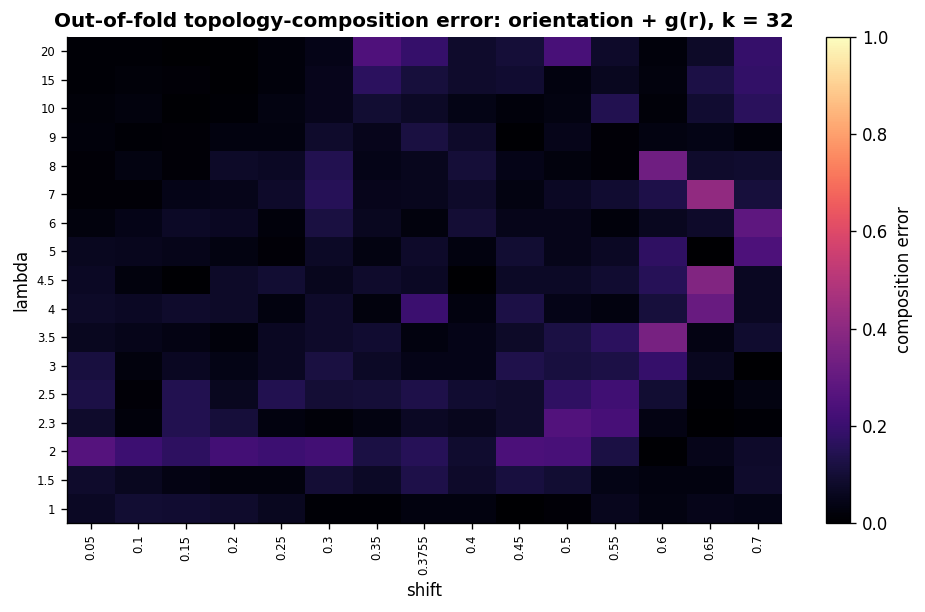

In [12]:
fig, ax = plt.subplots(figsize=(8.2, 5.2))
image = ax.imshow(state_grid(best, 'composition_error'), origin='lower', aspect='auto',
                  cmap='magma', vmin=0, vmax=1)
ax.set(
    title='Out-of-fold topology-composition error: orientation + g(r), k = 32',
    xlabel='shift', ylabel='lambda',
    xticks=np.arange(len(shift_values)), xticklabels=[f'{value:g}' for value in shift_values],
    yticks=np.arange(len(lambda_values)), yticklabels=[f'{value:g}' for value in lambda_values],
)
ax.tick_params(axis='x', labelrotation=90, labelsize=7)
ax.tick_params(axis='y', labelsize=7)
fig.colorbar(image, ax=ax, label='composition error')
plt.tight_layout()
plt.show()

**How to read these maps.** White is zero fraction and the class-specific colour is a fraction of one. The final map is the total difference between a predicted and observed five-component composition vector.

**Conclusion.** The prediction captures the broad state-dependent changes in topology composition. The error map identifies parameter regions where the local spectral neighbourhood is less representative, rather than hiding those failures inside a single global score.

## 7. Take-home messages

1. A spectral neighbourhood built from orientation + g(r) most accurately recovers the measured topology composition of held-out state points.
2. This conclusion is robust over a broad connected range of neighbourhood sizes; k = 32 is a stable choice.
3. g(r) is a compact structural baseline, while orientational information adds the distinction needed for the strongest topology-state recovery.
4. The out-of-fold maps show both where the state diagram is recovered well and where its topology changes remain difficult to interpolate.

# Appendix: all ablation input subsets

The full ablation contains every non-empty combination of the five feature groups: 31 subsets in total. The table lists the descriptor groups and dimension for each tested representation.

In [13]:
ablation = pd.read_csv(ABLATION / 'data' / 'full_group_ablation_summary.csv')
friendly_group_names = {
    'global': 'global',
    'orientation': 'orientation',
    'Rg': 'Rg',
    'gofr': 'g(r)',
    'crystallinity_coarse_histogram_features': 'crystallinity histograms',
}
all_subsets = ablation[['included_groups', 'n_input_columns', 'includes_global', 'fully_connected']].copy()
all_subsets['feature groups'] = all_subsets['included_groups'].str.split(';').map(
    lambda groups: ' + '.join(friendly_group_names[group] for group in groups)
)
all_subsets = all_subsets.rename(columns={
    'n_input_columns': 'variables',
    'includes_global': 'contains global observables',
    'fully_connected': 'k = 32 graph connected',
})
all_subsets[['feature groups', 'variables', 'contains global observables', 'k = 32 graph connected']].sort_values(
    ['variables', 'feature groups']
).reset_index(drop=True)

,feature groups,variables,contains global observables,k = 32 graph connected
0,global,6,True,True
1,crystallinity histograms,20,False,False
2,orientation,24,False,True
3,g(r),25,False,True
4,global + crystallinity histograms,26,True,False
5,Rg,29,False,True
6,global + orientation,30,True,True
7,global + g(r),31,True,True
8,global + Rg,35,True,True
9,orientation + crystallinity histograms,44,False,True


## Physical-consistency context

These are supporting results, not the primary presentation score. The recorded physical checks assess whether graph neighbours have similar mean bond number and mean cluster size. They do not summarize every physical property relevant to the system. Representations containing the global bond and size observables are excluded from the reduced physical ranking.

In [14]:
ablation = pd.read_csv(ABLATION / 'data' / 'full_group_ablation_summary.csv')
physical_context = ablation.loc[
    ablation['feature_set'].isin(['gofr', 'orientation__gofr', 'orientation__Rg',
                                  'global__orientation__Rg__gofr__crystallinity_coarse_histogram_features'])
].copy()
physical_context['representation'] = physical_context['feature_set'].replace({
    'gofr': 'g(r)',
    'orientation__gofr': 'orientation + g(r)',
    'orientation__Rg': 'orientation + Rg',
    'global__orientation__Rg__gofr__crystallinity_coarse_histogram_features': 'full reference',
})
physical_context[['representation', 'mean_bonds_1_8_spearman', 'mean_size_spearman',
                  'physical_quality_rank', 'full_overlap_mean']].rename(columns={
    'mean_bonds_1_8_spearman': 'bond Spearman',
    'mean_size_spearman': 'mean-size Spearman',
    'physical_quality_rank': 'reduced physical rank',
    'full_overlap_mean': 'full-graph neighbourhood overlap',
})

,representation,bond Spearman,mean-size Spearman,reduced physical rank,full-graph neighbourhood overlap
0,full reference,0.992398,0.975054,NaN,1.000000
4,g(r),0.993367,0.983054,3.5,0.367099
10,orientation + Rg,0.977035,0.936453,24.0,0.624100
11,orientation + g(r),0.991839,0.978003,8.0,0.444180


The complete 31-combination ablation is available in `results/.../ablation/data/full_group_ablation_summary.csv`; the full robustness diagnostics are in `results/.../ablation/spectral_neighbourhood_robustness_final/data/`.